# 🧠 Phase 3: Model Training & Selection
**Author:** Kyrylo Kudrevych

Welcome to the core of the project! 🚀

### 🎯 What are we doing here?
We have our clean data and our optimal settings (found via Optuna). Now, it is time to actually train the AI.
In this notebook, we will:
* Safely split our data to prevent cheating (data leakage).
* Train 4 different Machine Learning algorithms.
* Attempt to combine them into an "Ensemble" team.
* Compare their final MAE (Mean Absolute Error) to crown a winner!

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_absolute_error

from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

## 🛡️ 1. Safe Data Splitting
Before training, we must hide 20% of our data to use as a "final exam" for the models.

**Important:** We have missing values in the `floor_num` column. To avoid "data leakage" (accidentally letting the model peek at the test data), we calculate the median floor using *only* the training data, and then apply that specific number to both datasets.

In [2]:
df = pd.read_parquet('notebooks_data/data_ready_for_ml.parquet')

X = df.drop(columns=['true_price'])

# Compress prices using log1p
y_log1p = np.log1p(df['true_price'])

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_log1p, test_size=0.2, random_state=52)

# Safely handle missing floors
train_floor_median = X_train['floor_num'].median()
X_train['floor_num'] = X_train['floor_num'].fillna(train_floor_median)
X_test['floor_num'] = X_test['floor_num'].fillna(train_floor_median)

## 🤖 2. Training the Models
Now we will train all four models using the "Best Parameters" we discovered in the previous notebook. We will also calculate the MAE for each one to see how far off their predictions are in standard PLN.

In [3]:
# --- 1. RANDOM FOREST ---
rf_model = RandomForestRegressor(
    random_state=52,
    n_estimators=300,
    max_depth=19,
    min_samples_split=8,
    min_samples_leaf=1,
    max_features=1.0
)

rf_model.fit(X_train, y_train)

# Reversing the log transformation to get real PLN prices
rf_final_preds = np.expm1(rf_model.predict(X_test))
rf_final_y_test = np.expm1(y_test)

rf_mae = mean_absolute_error(rf_final_y_test, rf_final_preds)
print(f"RandomForest MAE: {rf_mae:.2f} PLN")

RandomForest MAE: 329.18 PLN


In [4]:
# --- 2. LIGHTGBM ---
lgb_model = lgb.LGBMRegressor(
    learning_rate=0.07745984184773047,
    n_estimators=1048,
    num_leaves=6,
    max_depth=6,
    min_child_samples=42,
    subsample=0.6408163463084459,
    colsample_bytree=0.5611273582943955,
    random_state=52,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

lgb_final_preds = np.expm1(lgb_model.predict(X_test))
lgb_final_y_test = np.expm1(y_test)

lgb_mae = mean_absolute_error(lgb_final_y_test, lgb_final_preds)
print(f"LightGBM MAE: {lgb_mae:.2f} PLN")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[299]	valid_0's l1: 0.0960907	valid_0's l2: 0.0165406
LightGBM MAE: 309.72 PLN


In [5]:
# --- 3. XGBOOST ---
xgb_model = xgb.XGBRegressor(
    learning_rate=0.013610240794734597,
    n_estimators=1090,
    max_depth=4,
    min_child_weight=24,
    subsample=0.5000107378967243,
    colsample_bytree=0.6124957316933373,
    objective='reg:squarederror',
    random_state=52,
    verbosity=0
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_final_preds = np.expm1(xgb_model.predict(X_test))
xgb_final_y_test = np.expm1(y_test)

xgb_mae = mean_absolute_error(xgb_final_y_test, xgb_final_preds)
print(f"XGBoost MAE: {xgb_mae:.2f} PLN")

XGBoost MAE: 312.67 PLN


In [6]:
# --- 4. CATBOOST ---
cat_model = CatBoostRegressor(
    learning_rate=0.05767738103592037,
    iterations=1315,
    depth=7,
    l2_leaf_reg=6.017436094131373,
    subsample=0.8546409021066528,
    loss_function='MAE',
    random_state=52,
    verbose=False
)

cat_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=50, verbose=False)

cat_final_preds = np.expm1(cat_model.predict(X_test))
cat_final_y_test = np.expm1(y_test)

cat_mae = mean_absolute_error(cat_final_y_test, cat_final_preds)
print(f"CatBoost MAE: {cat_mae:.2f} PLN")

CatBoost MAE: 307.66 PLN


## 🤝 3. The Ensemble Approach
In theory, combining multiple models into a "Voting Regressor" can cancel out individual mistakes. Let's group all four models together and give our best models (LightGBM and CatBoost) double voting weight to see if they can beat the single best score.

In [7]:
ensemble_model = VotingRegressor(
    estimators=[
        ('rf', rf_model),
        ('lightgbm', lgb_model),
        ('catboost', cat_model),
        ('xgb', xgb_model)
    ],
    weights=[1, 2, 2, 1] # Giving more power to LGB and CAT
)

ensemble_model.fit(X_train, y_train)

ensemble_final_preds = np.expm1(ensemble_model.predict(X_test))
ensemble_y_test = np.expm1(y_test)

ensemble_mae = mean_absolute_error(ensemble_y_test, ensemble_final_preds)
print(f"ENSEMBLE MAE: {ensemble_mae:.2f} PLN")

ENSEMBLE MAE: 311.76 PLN


In [8]:
print("\n--- FINAL MAE LEADERBOARD ---")
y_test_original = np.expm1(y_test)

for name, model in [('rf', rf_model), ('xgboost', xgb_model), ('lightgbm', lgb_model), ('catboost', cat_model), ('ensemble', ensemble_model)]:
    pred = np.expm1(model.predict(X_test))
    print(f"{name.upper()} MAE: {mean_absolute_error(y_test_original, pred):,.2f} PLN")


--- FINAL MAE LEADERBOARD ---
RF MAE: 329.18 PLN
XGBOOST MAE: 312.67 PLN
LIGHTGBM MAE: 309.72 PLN
CATBOOST MAE: 307.66 PLN
ENSEMBLE MAE: 311.76 PLN


## 🏆 4. Model Selection & Anomaly Hunting

**Final Results:**
* **Random Forest:** ~329 PLN
* **XGBoost:** ~312 PLN
* **LightGBM:** ~309 PLN
* **Ensemble:** ~311 PLN
* **CatBoost: ~307 PLN (WINNER! 🥇)**

**Why did the Ensemble lose?** Because Random Forest and XGBoost are noticeably weaker on this specific dataset. When we force them to vote alongside CatBoost, they actually drag CatBoost's high accuracy down! Simpler is better here: we will proceed with just CatBoost.

### Visualizing the Errors
Before we save the model for our UI, let's plot **Actual vs Predicted Prices**. We want to look for "Max Error" anomalies (houses where the model completely guessed wrong).

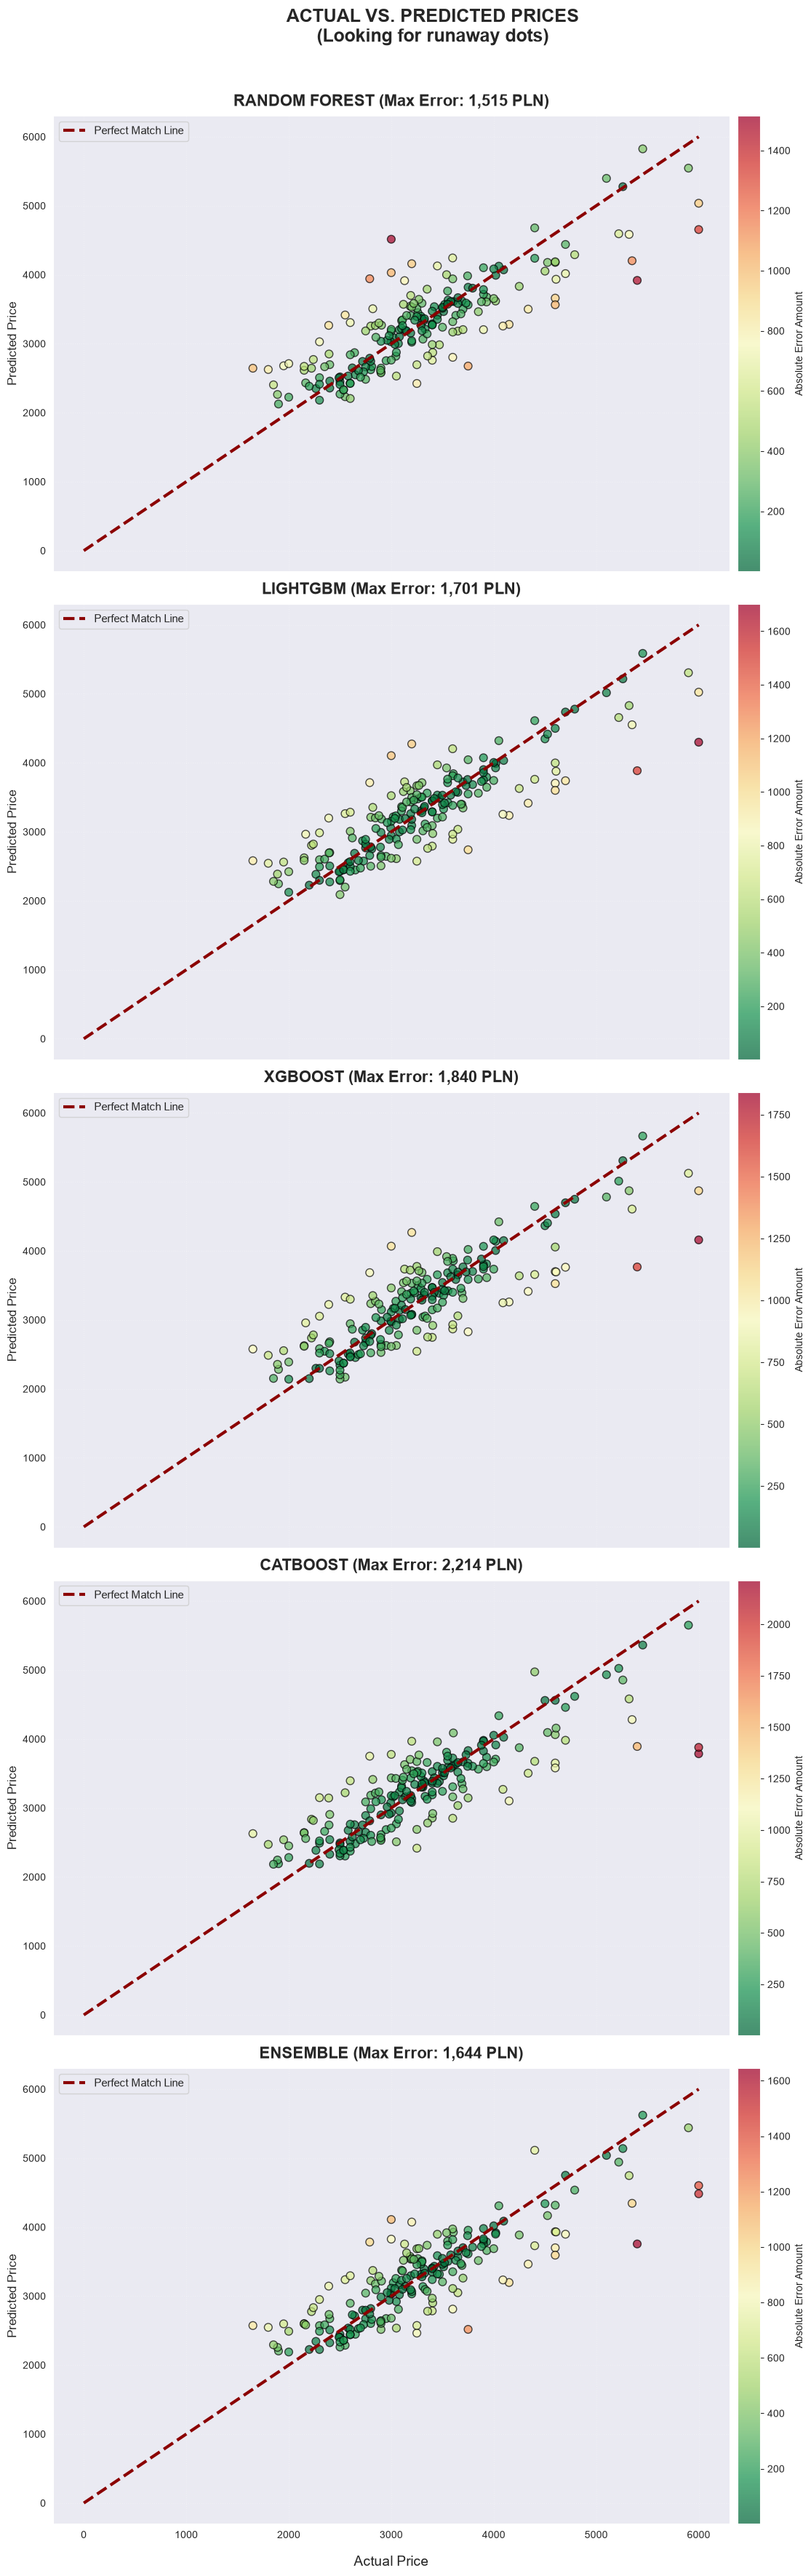

In [9]:
import matplotlib.pyplot as plt

models_preds = {
    'Random Forest': rf_final_preds,
    'LightGBM': lgb_final_preds,
    'XGBoost': xgb_final_preds,
    'CatBoost': cat_final_preds,
    'Ensemble': ensemble_final_preds
}

fig, axes = plt.subplots(5, 1, figsize=(12, 35), sharex=True)

max_val = max(y_test_original.max(), max([p.max() for p in models_preds.values()]))

for ax, (name, preds) in zip(axes, models_preds.items()):
    errors = np.abs(y_test_original - preds)

    # Plot predictions colored by how wrong they are (Green = Good, Red = Bad)
    scatter = ax.scatter(y_test_original, preds, c=errors, cmap='RdYlGn_r',
                         alpha=0.7, edgecolors='black', s=60)

    # The perfect prediction line
    ax.plot([0, max_val], [0, max_val], color='darkred', linestyle='--', linewidth=3, label='Perfect Match Line')

    cbar = plt.colorbar(scatter, ax=ax, pad=0.01)
    cbar.set_label('Absolute Error Amount', fontsize=10)

    ax.set_title(f"{name.upper()} (Max Error: {errors.max():,.0f} PLN)", fontsize=16, fontweight='bold', pad=10)
    ax.set_ylabel("Predicted Price", fontsize=12)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(loc='upper left', fontsize=11)

axes[-1].set_xlabel("Actual Price", fontsize=14, labelpad=15)

plt.suptitle("ACTUAL VS. PREDICTED PRICES\n(Looking for runaway dots)", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 💾 5. Saving the Final Model
CatBoost has the lowest average error. We can see from the scatter plot that it occasionally makes a massive over-prediction on weird luxury houses, but for 99% of regular apartments, it is highly accurate.

We will save this model to a `.pkl` file. Later, we can add a simple "Price Cap" inside our UI code to protect against those rare luxury-house mathematical glitches.

In [10]:
import pickle

# Using a relative path so this works no matter where the folder is moved
# Make sure you have a 'models' folder created in your project directory!
save_path = '../models/catboost_housing_model.pkl'

with open(save_path, 'wb') as file:
    pickle.dump(cat_model, file)

print("Winning CatBoost model successfully saved!")

Winning CatBoost model successfully saved!
